# CBL/VDL Packet User Walkthrough

Build a CBL/VDL interpretation packet from DLIS data one stage at a time, starting with a reusable template and finishing with the repeat pass.

## Who This Notebook Is For

A geologist, petrophysicist, or subsurface engineer who wants a concrete example of how `wellplot` reconstructs a CBL/VDL packet from public or repository-backed DLIS data.

## What You Will Learn

- how to inspect the source data and confirm which channels and header fields are available
- how to separate reusable template work from well-specific logfile work
- how to validate YAML and template wiring with `load_logfile(...)`
- how to render a packet with `render_from_logfile(...)` after each major edit
- how to add headings, remarks, tracks, curve bindings, fills, and extra sections in a controlled order

Prerequisites:

- `pip install "wellplot[dlis,notebook]"`
- run the notebook from a checkout of this repository so the `examples/` files and sample data are available

## The Three `wellplot` Functions That Matter In This Workflow

- `load_datasets_for_logfile(...)` to inspect the source file and list the channels you can actually plot
- `load_logfile(...)` to validate the YAML and the template resolution before you render
- `render_from_logfile(...)` to produce the packet PDF once the YAML is ready

## How To Read This Notebook

- each stage writes a real YAML file under `workspace/tutorials/`
- each render cell validates and renders that stage exactly like a real user workflow
- the inline images are visual checkpoints so you can compare your result with the expected packet state


In [1]:
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active environment "
        "before running this notebook."
    ) from exc

cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository so the "
        "example files and sample data are available."
    )

package_dir = REPO_ROOT / "examples" / "production" / "cbl_log_example"
example_logfile = package_dir / "full_reconstruction.log.yaml"
tutorial_dir = REPO_ROOT / "workspace" / "tutorials" / "cbl_log_example"
render_dir = tutorial_dir / "renders"
tutorial_dir.mkdir(parents=True, exist_ok=True)
render_dir.mkdir(parents=True, exist_ok=True)

print("wellplot version:", wellplot.__version__)
print("Production example:", example_logfile.relative_to(REPO_ROOT))
print("Tutorial workspace:", tutorial_dir.relative_to(REPO_ROOT))
print("Render output folder:", render_dir.relative_to(REPO_ROOT))


wellplot version: 0.1.0
Production example: examples/production/cbl_log_example/full_reconstruction.log.yaml
Tutorial workspace: workspace/tutorials/cbl_log_example
Render output folder: workspace/tutorials/cbl_log_example/renders


## Inspect The Source Data Before You Design The Plot

A practical workflow starts by confirming two things:

- which channels are available in the source file
- which metadata fields are good enough to populate the heading

Use the shipped `cbl_log_example` example as the inspection source, then copy the same pattern to your own well.


In [2]:
from wellplot import load_datasets_for_logfile, load_logfile

spec = load_logfile(example_logfile)
datasets_by_section, _source_paths = load_datasets_for_logfile(spec, base_dir=example_logfile.parent)
dataset = datasets_by_section["main_pass"]

wanted_channels = ['ECGR_STGC', 'TT', 'TENS', 'MTEM', 'CBL', 'VDL', 'STIT', 'TDSP', 'VSEC']
available_channels = [channel for channel in wanted_channels if channel in dataset.channels]
print("Sections available:", ", ".join(datasets_by_section))
print("Channels used in this tutorial:", ", ".join(available_channels))
print("Header fields available from the source data:")
for key in ['COMP', 'WELL', 'FIELD', 'WELL_ID']:
    print(f"  {key}: {dataset.well_metadata.get(key)}")


Sections available: main_pass, repeat_pass
Channels used in this tutorial: ECGR_STGC, TT, TENS, MTEM, CBL, VDL, STIT, TDSP, VSEC
Header fields available from the source data:
  COMP: University of Utah
  WELL: Forge 78B-32
  FIELD: None
  WELL_ID: NRC


## Create The Reusable Template First

This file should hold the decisions that you expect to reuse for many wells.

- The CBL template owns the reusable packet identity: page geometry, heading content, track-header styling, and tail behavior.
- The logfile owns job-specific content: DLIS source paths, which pass to plot, which tracks to show, and which channels to bind.
- That split matters because most real CBL work reuses one packet style across many jobs while only the logfile changes.

Write the template once, then keep the later stage files focused on data sources, sections, tracks, and bindings.


In [3]:
template_path = tutorial_dir / "base.template.yaml"
template_text = '''
render:
  backend: matplotlib
  output_path: ./renders/tutorial_template_placeholder.pdf
  dpi: 180
  continuous_strip_page_height_mm: 297
  matplotlib:
    style:
      report:
        summary_label_fontsize: 8.0
        summary_value_fontsize: 10.5
        provider_fontsize: 16.0
        service_fontsize: 7.5
        tail_service_fontsize: 7.5
        field_label_fontsize: 7.0
        field_value_fontsize: 7.8
        detail_header_fontsize: 9.0
        detail_label_fontsize: 6.4
        detail_value_fontsize: 6.4
        tail_frame_y: 0.74
        tail_frame_height: 0.22
      section_title:
        background_color: '#f7f7f7'
        border_mode: bottom_rule
        border_color: '#2b2b2b'
        border_linewidth: 0.9
        height_mm: 11.0
        padding_left: 0.03
        padding_right: 0.03
        title_align: center
        subtitle_align: center
        title_fontsize: 11.5
        subtitle_fontsize: 6.8
        title_y: 0.68
        subtitle_y: 0.22
      track_header:
        background_color: '#e8e8e8'
        separator_color: '#5a5a5a'
        separator_linewidth: 0.4
      track:
        x_tick_labelsize: 6.0
      grid:
        depth_major_linewidth: 0.65
document:
  depth_range:
  - 100
  - 8489
  page:
    size: A4
    orientation: portrait
    continuous: false
    bottom_track_header_enabled: true
    margin_left_mm: 0
    margin_right_mm: 8
    margin_top_mm: 0
    margin_bottom_mm: 0
    track_gap_mm: 0
    header_height_mm: 0
    track_header_height_mm: 30
    footer_height_mm: 0
  depth:
    unit: ft
    scale: 240
    major_step: 10
    minor_step: 2
  layout:
    heading:
      enabled: true
      provider_name: Company
      general_fields:
      - key: company
        label: Company
        value: University of Utah
      - key: well
        label: Well
        value: Forge 78B-32
      - key: field
        label: Field
        value: None
      - key: location
        label: Location
        value: 'Lat: 38.500171 Long: -112.88221'
      - key: logging_date
        label: Logging Date
        value: 06-Oct-2021
      - key: scale
        label: Scale
        value: ft 1:240
      - key: fluid_type
        label: Casing Fluid Type
        value: Water
      service_titles:
      - value: Cement Bond Log
        font_size: 16
        auto_adjust: true
        bold: true
        alignment: left
      - value: Variable Density Log
        font_size: 15
        auto_adjust: true
        italic: true
        alignment: center
      - value: Gamma Ray - CCL
        font_size: 14
        auto_adjust: true
        alignment: right
      detail:
        kind: cased_hole
        title: Cased Hole
        rows:
        - label: Date
          values:
          - 06-Oct-2021
          - ''
        - label_cells:
          - Run
          - Direction
          columns:
          - cells:
            - ONE
          - cells:
            - Up / Down
        - label: Service Order
          values:
          - NRC 42-00090-03
          - ''
        - label: Driller Depth
          columns:
          - cells:
            - 8540.0
            - ft
          - cells:
            - ''
        - label: Logged Depth
          columns:
          - cells:
            - 8540.0
            - ft
          - cells:
            - ''
        - label: First Reading (Bottom)
          columns:
          - cells:
            - 8489.0
            - ft
          - cells:
            - ''
    remarks:
    - title: Public Data and IP Notice
      lines:
      - This tutorial uses publicly available or repository-provided demonstration
        data intended for educational use.
      - Rendered layouts are independent reproductions generated by wellplot, not
        vendor-authored originals or official service-company deliverables.
      alignment: left
    log_sections: []
    tail:
      enabled: true
  bindings:
    on_missing: skip
    channels: []
'''
template_path.write_text(template_text)

print("Wrote:", template_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/cbl_log_example/base.template.yaml


## Step 1. Build the first main-pass packet

Start with the heading, remarks, one main-pass section, and a small combo track so you can prove that the packet skeleton is correct before you add the heavier CBL/VDL features.

What this step teaches:

- A production packet can begin with only one pass and only a few curves.
- The depth track still defines layout even before you add special overlay indicators.
- This is the right stage to verify that the DLIS source path, page scale, and headings are all correct.


In [4]:
step_1_first_packet_logfile_path = tutorial_dir / "step_1_first_packet.log.yaml"
step_1_first_packet_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: CBL tutorial step 1 - first packet
render:
  output_path: ./renders/step_1_first_packet.pdf
document:
  layout:
    remarks:
    - title: What this first packet proves
      lines:
      - The heading, remarks, and first main-pass section are all connected to the
        DLIS-backed packet.
      - You do not need every CBL feature on the first pass; prove the packet structure
        first.
      alignment: left
    log_sections:
    - id: main_pass
      title: Main Pass
      subtitle: CBL_Main.dlis
      data:
        source_path: ../../data/CBL_Main.dlis
        source_format: dlis
      tracks:
      - id: combo
        title: ''
        kind: normal
        width_mm: 50
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 36
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      depth_range:
      - 8230
      - 8490
  bindings:
    channels:
    - section: main_pass
      channel: ECGR_STGC
      track_id: combo
      kind: curve
      label: Gamma Ray (ECGR_STGC) QTGC-B
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
    - section: main_pass
      channel: TT
      track_id: combo
      kind: curve
      label: Transit Time for CBL (TT) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: 200
        max: 400
        reverse: true
'''
step_1_first_packet_logfile_path.write_text(step_1_first_packet_logfile_text)

print("Wrote:", step_1_first_packet_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/cbl_log_example/step_1_first_packet.log.yaml


Validated: CBL tutorial step 1 - first packet
Pages created: 4
PDF written to: workspace/tutorials/cbl_log_example/renders/step_1_first_packet.pdf


### Opening page after step 1

The packet already has headings and remarks even though the log content is still minimal.

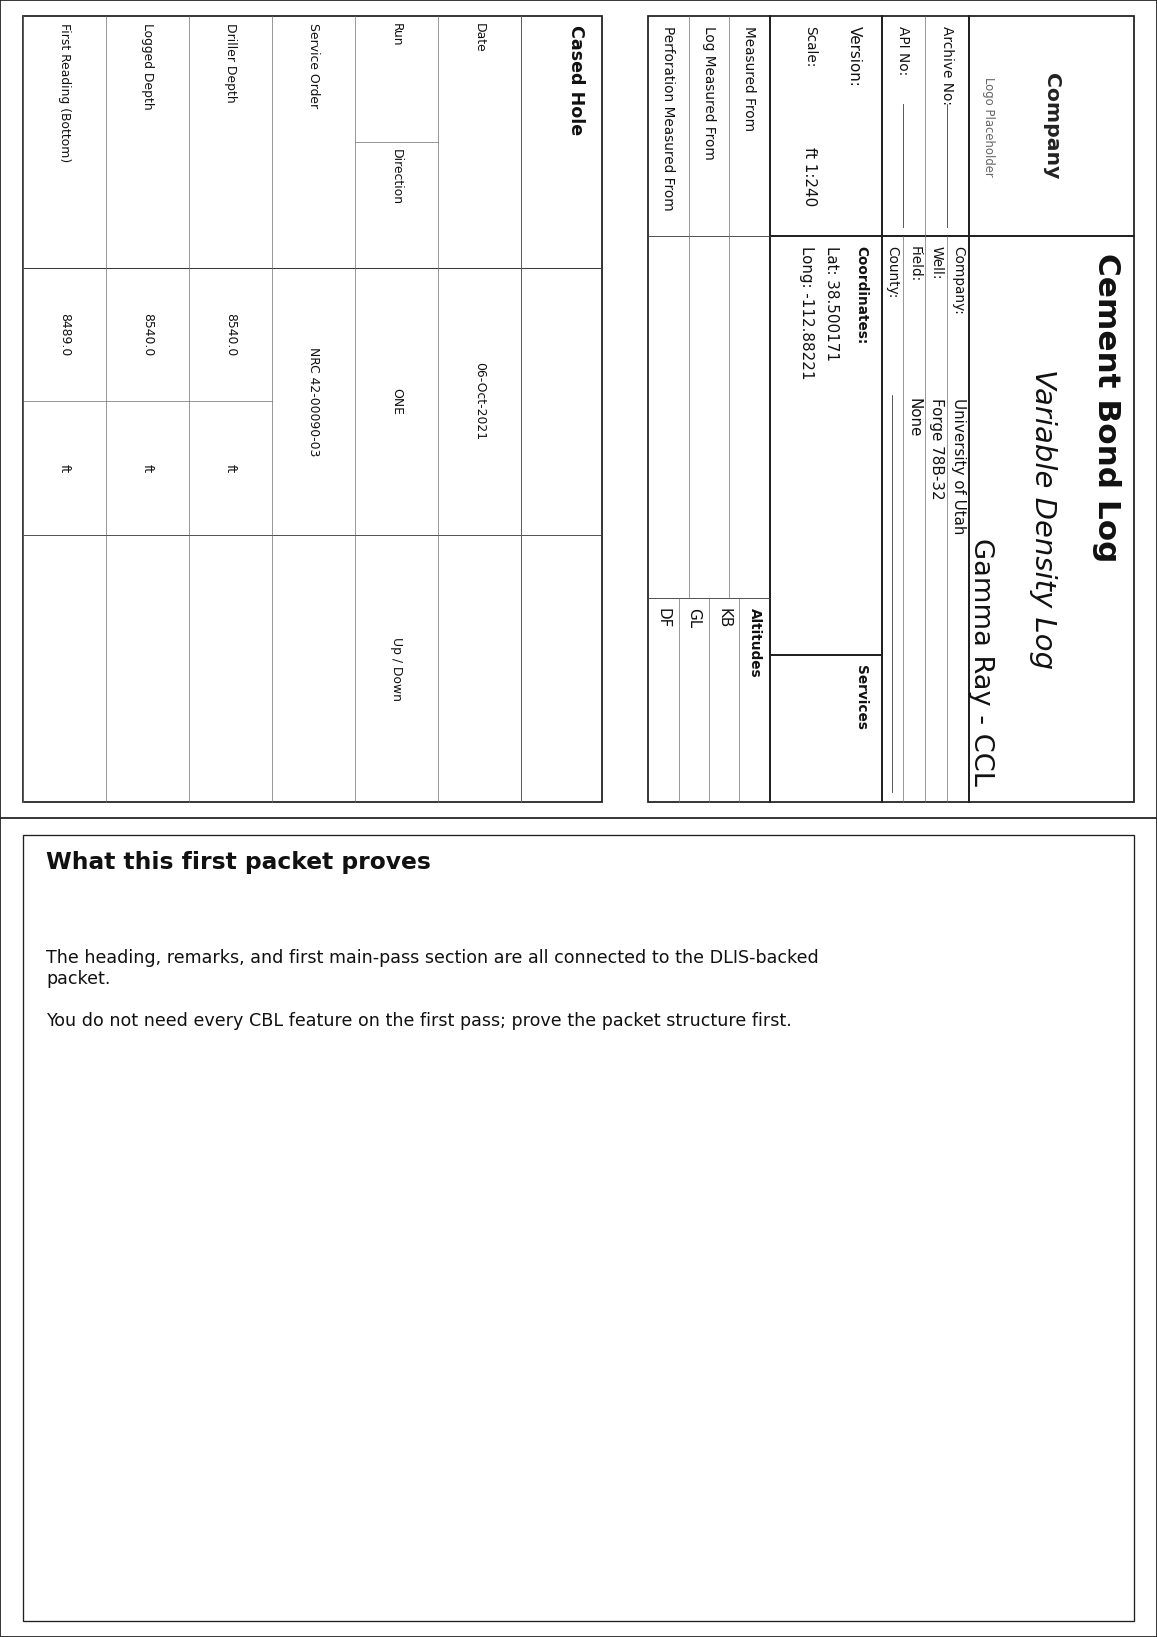

### Main-pass skeleton after step 1

The first strip proves the packet layout with only the combo and depth tracks.

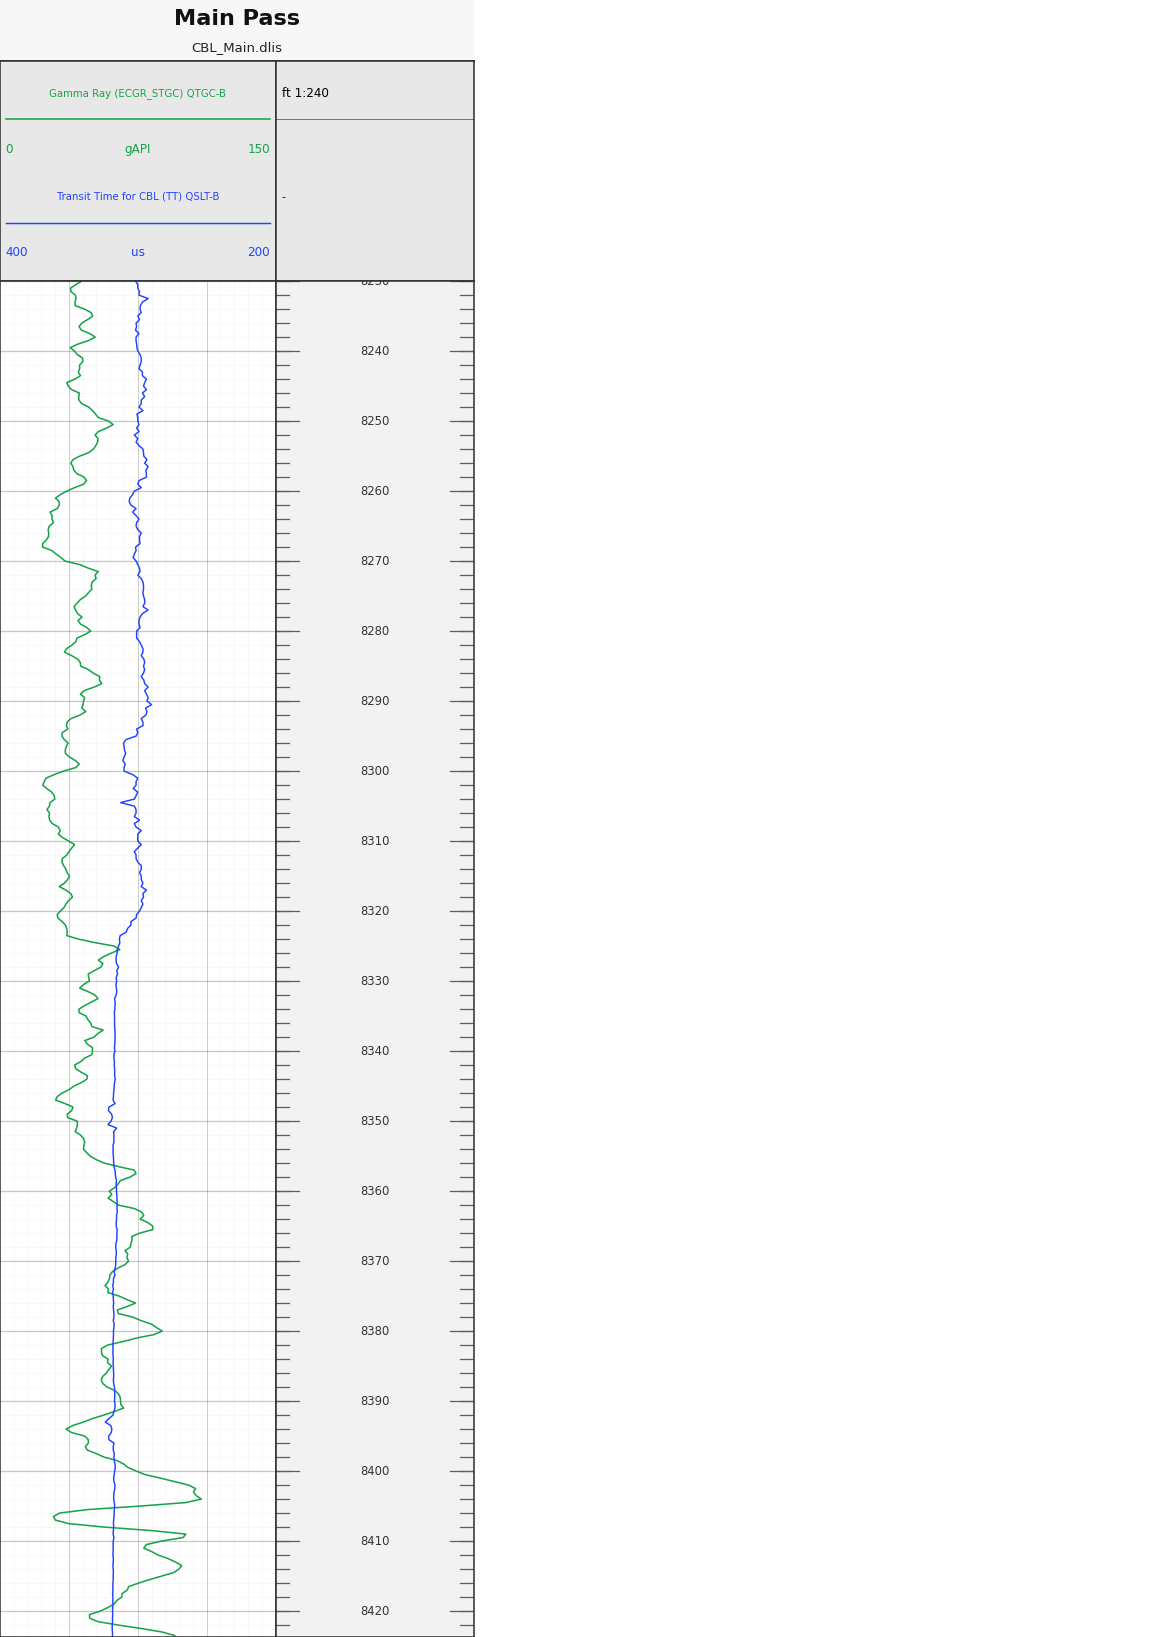

In [5]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_1_first_packet_logfile_path)
result = render_from_logfile(step_1_first_packet_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 2. Add the dedicated CBL amplitude track

Bind the same CBL channel twice so the packet shows both the broad and tight amplitude scales that make cement interpretation easier.

What this step teaches:

- One channel can be plotted more than once when each binding serves a different reading task.
- The packet gets easier to read when the CBL amplitude leaves the crowded combo track and gets its own track.
- This is also the stage where supporting combo curves such as tension and mud temperature become more useful.


In [6]:
step_2_add_cbl_track_logfile_path = tutorial_dir / "step_2_add_cbl_track.log.yaml"
step_2_add_cbl_track_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: CBL tutorial step 2 - add the CBL amplitude track
render:
  output_path: ./renders/step_2_add_cbl_track.pdf
document:
  layout:
    remarks:
    - title: Why the dedicated CBL track matters
      lines:
      - The same CBL channel can be bound twice so the packet shows both the broad
        0 to 100 scale and the tighter 0 to 10 scale.
      - This is a good example of how one channel can support more than one interpretation
        view.
      alignment: left
    log_sections:
    - id: main_pass
      title: Main Pass
      subtitle: CBL_Main.dlis
      data:
        source_path: ../../data/CBL_Main.dlis
        source_format: dlis
      tracks:
      - id: combo
        title: ''
        kind: normal
        width_mm: 50
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 36
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: cbl
        title: ''
        kind: normal
        width_mm: 44
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 2
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      depth_range:
      - 8230
      - 8490
  bindings:
    channels:
    - section: main_pass
      channel: ECGR_STGC
      track_id: combo
      kind: curve
      label: Gamma Ray (ECGR_STGC) QTGC-B
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
    - section: main_pass
      channel: TT
      track_id: combo
      kind: curve
      label: Transit Time for CBL (TT) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: 200
        max: 400
        reverse: true
    - section: main_pass
      channel: TENS
      track_id: combo
      kind: curve
      label: Cable Tension (TENS)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 5000
        max: 0
    - section: main_pass
      channel: MTEM
      track_id: combo
      kind: curve
      label: Mud Temperature (MTEM) LEH-MT
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.9
      scale:
        kind: linear
        min: 100
        max: 500
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_100_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 0
        max: 100
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_10_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2563eb'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
'''
step_2_add_cbl_track_logfile_path.write_text(step_2_add_cbl_track_logfile_text)

print("Wrote:", step_2_add_cbl_track_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/cbl_log_example/step_2_add_cbl_track.log.yaml


Validated: CBL tutorial step 2 - add the CBL amplitude track
Pages created: 4
PDF written to: workspace/tutorials/cbl_log_example/renders/step_2_add_cbl_track.pdf


### Main pass after step 2

The CBL amplitude track now carries both the wide and tight scales using two bindings to the same channel.

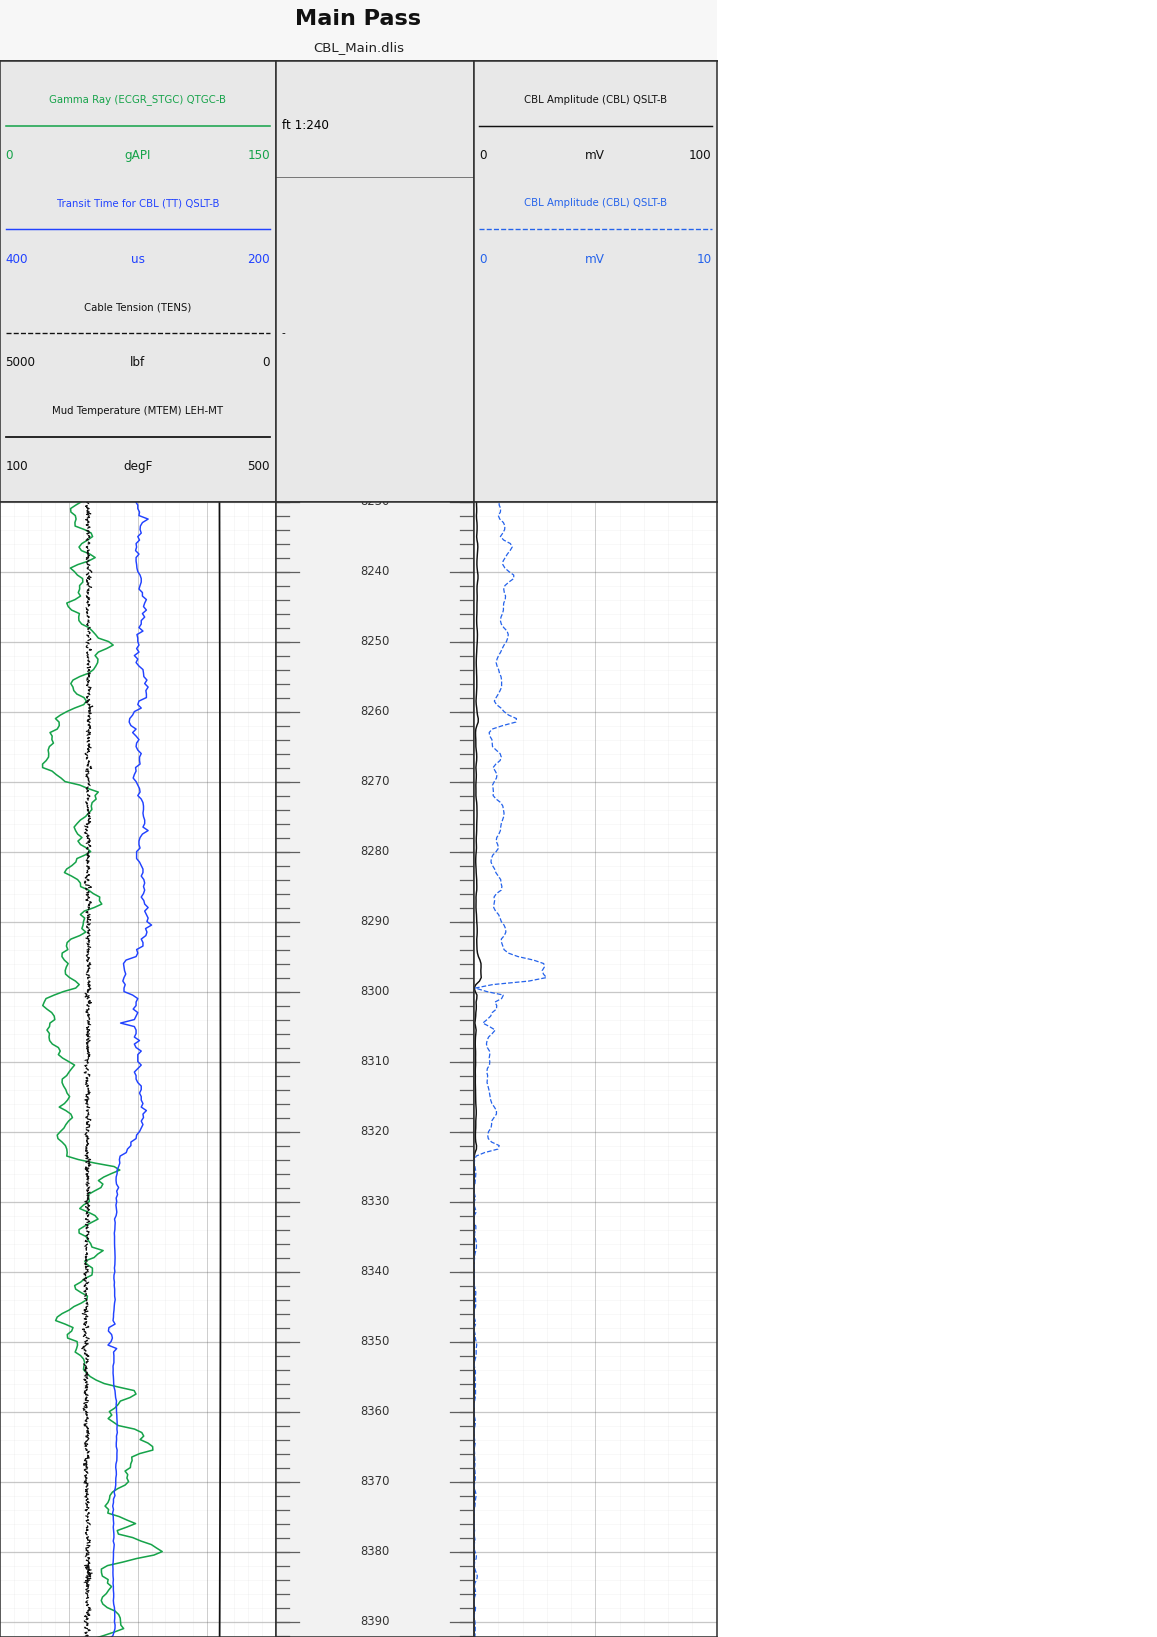

In [7]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_2_add_cbl_track_logfile_path)
result = render_from_logfile(step_2_add_cbl_track_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 3. Add the VDL array and depth overlays

Finish the main pass by adding the VDL raster and the local indicator overlays on the depth track.

What this step teaches:

- Array tracks are configured differently from normal tracks because they plot raster data instead of scalar curves.
- The sample-axis block tells wellplot how to label the VDL waveform axis in the header.
- Reference overlays let you add local indicators without giving up the depth track as the packet layout axis.


In [8]:
step_3_add_vdl_and_overlays_logfile_path = tutorial_dir / "step_3_add_vdl_and_overlays.log.yaml"
step_3_add_vdl_and_overlays_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: CBL tutorial step 3 - add VDL and depth overlays
render:
  output_path: ./renders/step_3_add_vdl_and_overlays.pdf
document:
  layout:
    remarks:
    - title: Why this is the key CBL interpretation step
      lines:
      - The VDL array track turns the packet from a simple curve sheet into a CBL/VDL
        interpretation view.
      - Reference overlays on the depth track keep local indicators visible without
        creating extra tracks.
      alignment: left
    log_sections:
    - id: main_pass
      title: Main Pass
      subtitle: CBL_Main.dlis
      data:
        source_path: ../../data/CBL_Main.dlis
        source_format: dlis
      tracks:
      - id: combo
        title: ''
        kind: normal
        width_mm: 50
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 36
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: cbl
        title: ''
        kind: normal
        width_mm: 44
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 2
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: vdl
        title: ''
        kind: array
        width_mm: 48
        position: 4
        x_scale:
          kind: linear
          min: 200
          max: 1200
        grid:
          vertical:
            main:
              visible: false
            secondary:
              visible: false
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      depth_range:
      - 8230
      - 8490
  bindings:
    channels:
    - section: main_pass
      channel: ECGR_STGC
      track_id: combo
      kind: curve
      label: Gamma Ray (ECGR_STGC) QTGC-B
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
    - section: main_pass
      channel: TT
      track_id: combo
      kind: curve
      label: Transit Time for CBL (TT) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: 200
        max: 400
        reverse: true
    - section: main_pass
      channel: TENS
      track_id: combo
      kind: curve
      label: Cable Tension (TENS)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 5000
        max: 0
    - section: main_pass
      channel: MTEM
      track_id: combo
      kind: curve
      label: Mud Temperature (MTEM) LEH-MT
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.9
      scale:
        kind: linear
        min: 100
        max: 500
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_100_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 0
        max: 100
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_10_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2563eb'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: main_pass
      channel: VDL
      track_id: vdl
      kind: raster
      label: VDL VariableDensity (VDL) QSLT-B
      profile: vdl
      normalization: auto
      waveform_normalization: trace_maxabs
      style:
        colormap: gray_r
      show_raster: true
      raster_alpha: 1.0
      colorbar:
        enabled: true
        label: Amplitude
        position: header
      sample_axis:
        enabled: true
        unit: us
        min: 200
        max: 1200
        source_origin: 40
        source_step: 10
        ticks: 7
    - section: main_pass
      channel: STIT
      track_id: depth
      kind: curve
      label: Stuck Tool Indicator, Total (STIT)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.06
        lane_end: 0.2
    - section: main_pass
      channel: TDSP
      track_id: depth
      kind: curve
      label: Cable Drag
      header_display:
        wrap_name: true
      style:
        color: '#92400e'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.24
        lane_end: 0.38
    - section: main_pass
      channel: VSEC
      track_id: depth
      kind: curve
      label: Tool_Tot. Drag
      header_display:
        wrap_name: true
      style:
        color: '#1d4ed8'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.8
        lane_end: 0.94
'''
step_3_add_vdl_and_overlays_logfile_path.write_text(step_3_add_vdl_and_overlays_logfile_text)

print("Wrote:", step_3_add_vdl_and_overlays_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/cbl_log_example/step_3_add_vdl_and_overlays.log.yaml


Validated: CBL tutorial step 3 - add VDL and depth overlays
Pages created: 4
PDF written to: workspace/tutorials/cbl_log_example/renders/step_3_add_vdl_and_overlays.pdf


### Main pass after step 3

The packet now has the VDL raster plus the stuck-tool and drag indicators on the depth track.

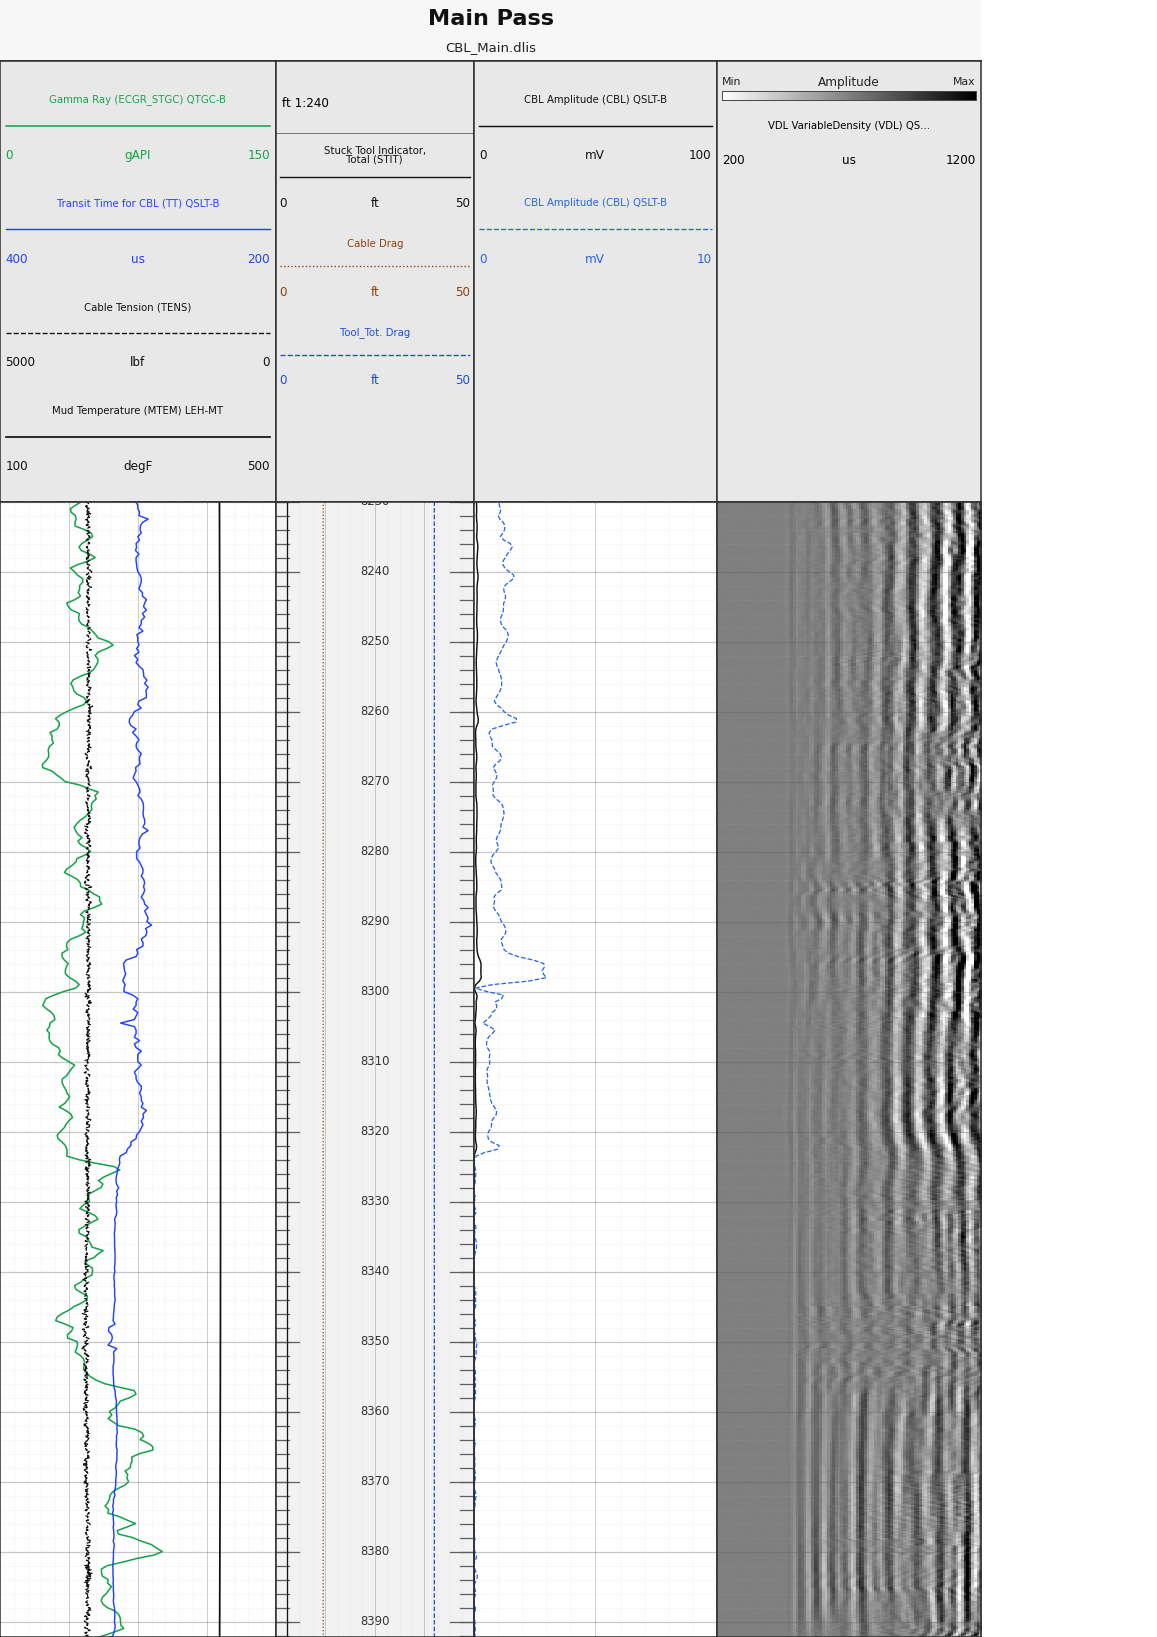

In [9]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_3_add_vdl_and_overlays_logfile_path)
result = render_from_logfile(step_3_add_vdl_and_overlays_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 4. Add the repeat pass and finish the packet

Reuse the same template and packet rules, then add the repeat pass so the final example covers the supported reconstruction scope.

What this step teaches:

- Repeat sections should reuse the same layout vocabulary unless the second pass truly needs a different design.
- The production remarks and public-data notice belong inside the final packet so the PDF can stand on its own.
- Once both passes are working, further edits should usually be curve styles, interval windows, or heading content rather than structural redesign.


In [10]:
step_4_final_packet_logfile_path = tutorial_dir / "step_4_final_packet.log.yaml"
step_4_final_packet_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: CBL tutorial step 4 - final packet with repeat pass
render:
  output_path: ./renders/step_4_final_packet.pdf
document:
  layout:
    remarks:
    - title: Supported Reconstruction Scope
      lines:
      - This production example reconstructs the supported pages of the original CBL/VDL
        packet.
      - Calibration reports, parameter listings, borehole sketches, and vendor disclaimers
        are intentionally omitted.
      - The main and repeat sections use the real DLIS files in the repository and
        preserve the source packet scale convention.
      alignment: left
    - title: Data Sources
      lines:
      - 'Main pass source: workspace/data/CBL_Main.dlis'
      - 'Repeat pass source: workspace/data/CBL_Repeat.dlis'
      - 'Shared index convention: measured depth in feet at 1:240 scale.'
      alignment: left
    - title: Public Data and IP Notice
      lines:
      - This example uses publicly available or repository-provided demonstration
        data intended for educational use.
      - Rendered layouts are independent reproductions generated by wellplot, not
        vendor-authored originals or official service-company deliverables.
      - Original trademarks and service names remain the property of their respective
        owners.
      - Confirm data provenance and redistribution rights before reusing outputs outside
        this repository.
      alignment: left
    log_sections:
    - id: main_pass
      title: Main Pass
      subtitle: CBL_Main.dlis
      data:
        source_path: ../../data/CBL_Main.dlis
        source_format: dlis
      tracks:
      - id: combo
        title: ''
        kind: normal
        width_mm: 50
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 36
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: cbl
        title: ''
        kind: normal
        width_mm: 44
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 2
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: vdl
        title: ''
        kind: array
        width_mm: 48
        position: 4
        x_scale:
          kind: linear
          min: 200
          max: 1200
        grid:
          vertical:
            main:
              visible: false
            secondary:
              visible: false
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      depth_range:
      - 8230
      - 8490
    - id: repeat_pass
      title: Repeat Pass
      subtitle: CBL_Repeat.dlis
      depth_range:
      - 8230
      - 8490
      data:
        source_path: ../../data/CBL_Repeat.dlis
        source_format: dlis
      tracks:
      - id: combo
        title: ''
        kind: normal
        width_mm: 50
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 36
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: cbl
        title: ''
        kind: normal
        width_mm: 44
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 2
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: vdl
        title: ''
        kind: array
        width_mm: 48
        position: 4
        x_scale:
          kind: linear
          min: 200
          max: 1200
        grid:
          vertical:
            main:
              visible: false
            secondary:
              visible: false
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
  bindings:
    channels:
    - section: main_pass
      channel: ECGR_STGC
      track_id: combo
      kind: curve
      label: Gamma Ray (ECGR_STGC) QTGC-B
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
    - section: main_pass
      channel: TT
      track_id: combo
      kind: curve
      label: Transit Time for CBL (TT) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: 200
        max: 400
        reverse: true
    - section: main_pass
      channel: TENS
      track_id: combo
      kind: curve
      label: Cable Tension (TENS)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 5000
        max: 0
    - section: main_pass
      channel: MTEM
      track_id: combo
      kind: curve
      label: Mud Temperature (MTEM) LEH-MT
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.9
      scale:
        kind: linear
        min: 100
        max: 500
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_100_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 0
        max: 100
    - section: main_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_10_main
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2563eb'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: main_pass
      channel: VDL
      track_id: vdl
      kind: raster
      label: VDL VariableDensity (VDL) QSLT-B
      profile: vdl
      normalization: auto
      waveform_normalization: trace_maxabs
      style:
        colormap: gray_r
      show_raster: true
      raster_alpha: 1.0
      colorbar:
        enabled: true
        label: Amplitude
        position: header
      sample_axis:
        enabled: true
        unit: us
        min: 200
        max: 1200
        source_origin: 40
        source_step: 10
        ticks: 7
    - section: main_pass
      channel: STIT
      track_id: depth
      kind: curve
      label: Stuck Tool Indicator, Total (STIT)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.06
        lane_end: 0.2
    - section: main_pass
      channel: TDSP
      track_id: depth
      kind: curve
      label: Cable Drag
      header_display:
        wrap_name: true
      style:
        color: '#92400e'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.24
        lane_end: 0.38
    - section: main_pass
      channel: VSEC
      track_id: depth
      kind: curve
      label: Tool_Tot. Drag
      header_display:
        wrap_name: true
      style:
        color: '#1d4ed8'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.8
        lane_end: 0.94
    - section: repeat_pass
      channel: ECGR_STGC
      track_id: combo
      kind: curve
      label: Gamma Ray (ECGR_STGC) QTGC-B
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
    - section: repeat_pass
      channel: TT
      track_id: combo
      kind: curve
      label: Transit Time for CBL (TT) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: 200
        max: 400
        reverse: true
    - section: repeat_pass
      channel: TENS
      track_id: combo
      kind: curve
      label: Cable Tension (TENS)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 5000
        max: 0
    - section: repeat_pass
      channel: MTEM
      track_id: combo
      kind: curve
      label: Mud Temperature (MTEM) LEH-MT
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.9
      scale:
        kind: linear
        min: 100
        max: 500
    - section: repeat_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_100_repeat
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 0
        max: 100
    - section: repeat_pass
      channel: CBL
      track_id: cbl
      kind: curve
      id: cbl_0_10_repeat
      label: CBL Amplitude (CBL) QSLT-B
      header_display:
        wrap_name: true
      style:
        color: '#2563eb'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: repeat_pass
      channel: VDL
      track_id: vdl
      kind: raster
      label: VDL VariableDensity (VDL) QSLT-B
      profile: vdl
      normalization: auto
      waveform_normalization: trace_maxabs
      style:
        colormap: gray_r
      show_raster: true
      raster_alpha: 1.0
      colorbar:
        enabled: true
        label: Amplitude
        position: header
      sample_axis:
        enabled: true
        unit: us
        min: 200
        max: 1200
        source_origin: 40
        source_step: 10
        ticks: 7
    - section: repeat_pass
      channel: STIT
      track_id: depth
      kind: curve
      label: Stuck Tool Indicator, Total (STIT)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.65
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.06
        lane_end: 0.2
    - section: repeat_pass
      channel: TDSP
      track_id: depth
      kind: curve
      label: Cable Drag
      header_display:
        wrap_name: true
      style:
        color: '#92400e'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.24
        lane_end: 0.38
    - section: repeat_pass
      channel: VSEC
      track_id: depth
      kind: curve
      label: Tool_Tot. Drag
      header_display:
        wrap_name: true
      style:
        color: '#1d4ed8'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 50
      reference_overlay:
        mode: indicator
        lane_start: 0.8
        lane_end: 0.94
'''
step_4_final_packet_logfile_path.write_text(step_4_final_packet_logfile_text)

print("Wrote:", step_4_final_packet_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/cbl_log_example/step_4_final_packet.log.yaml


Validated: CBL tutorial step 4 - final packet with repeat pass
Pages created: 6
PDF written to: workspace/tutorials/cbl_log_example/renders/step_4_final_packet.pdf


### Opening page of the final tutorial packet

The final packet has the production remarks and keeps the public-data / IP boundary explicit.

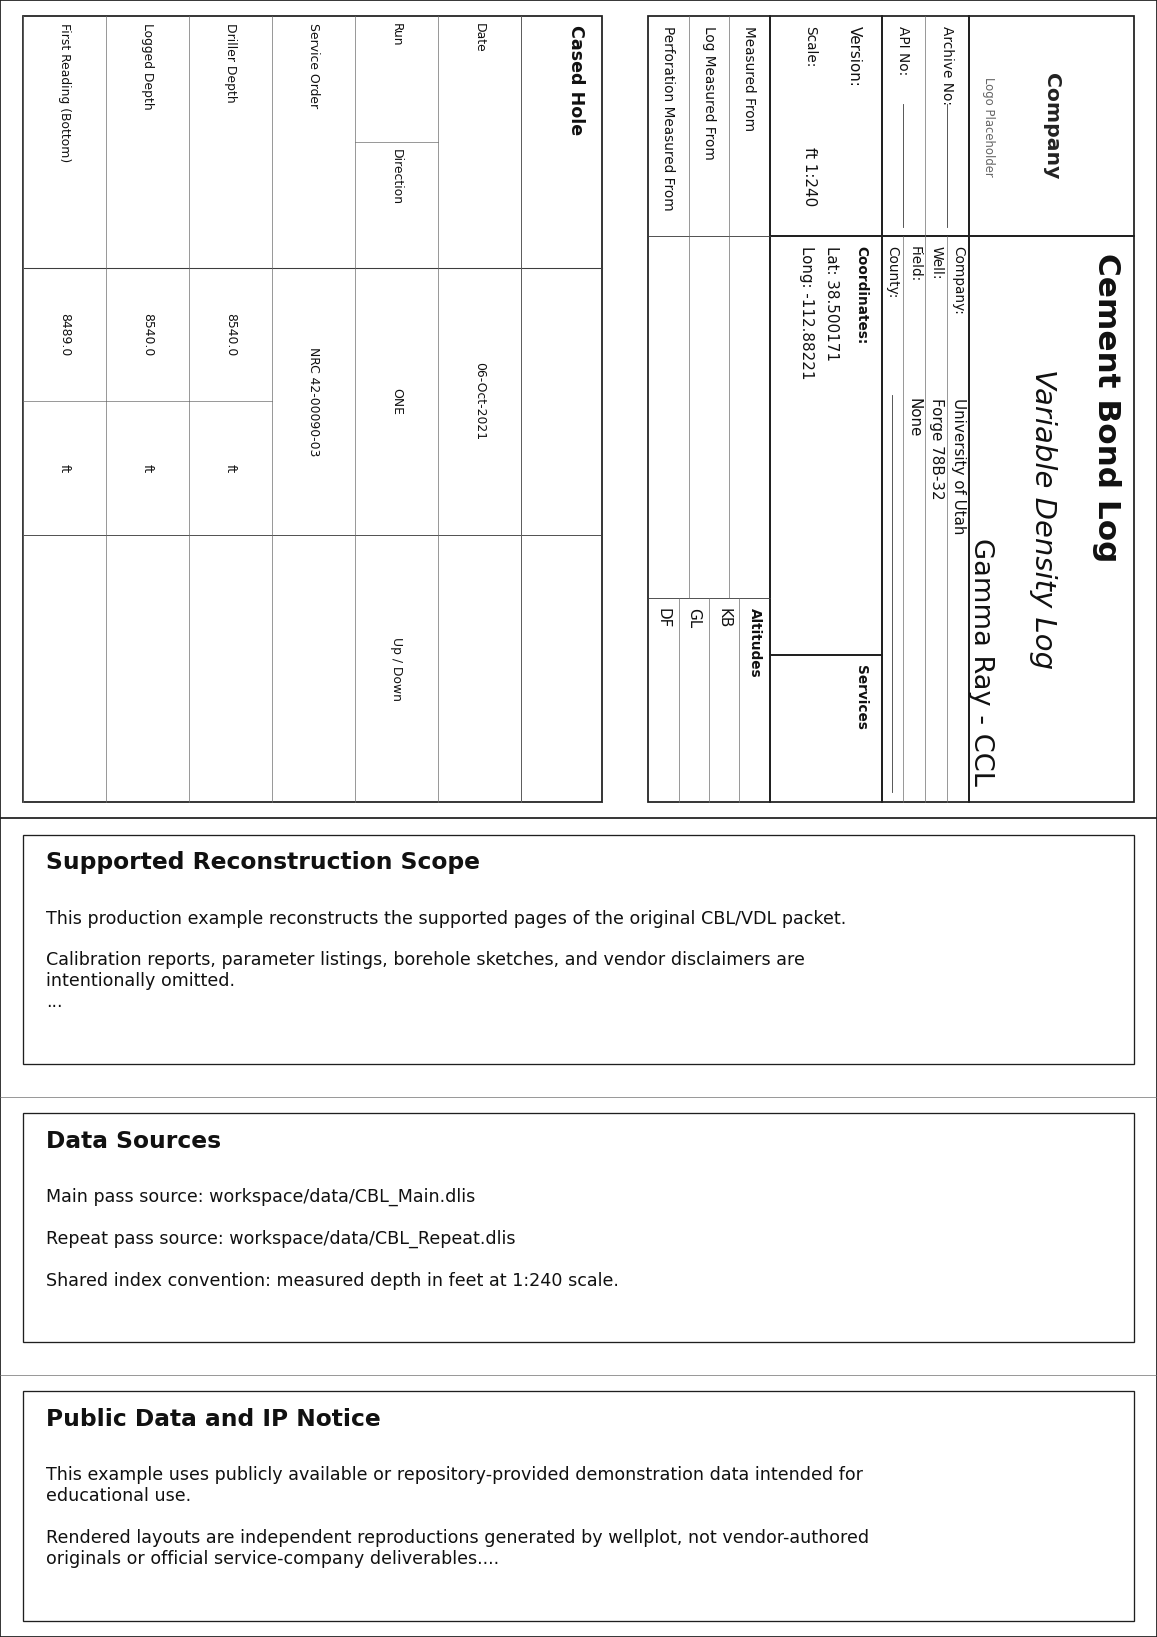

### Repeat-pass section

The repeat pass reuses the same packet structure so the second DLIS file drops into a familiar interpretation view.

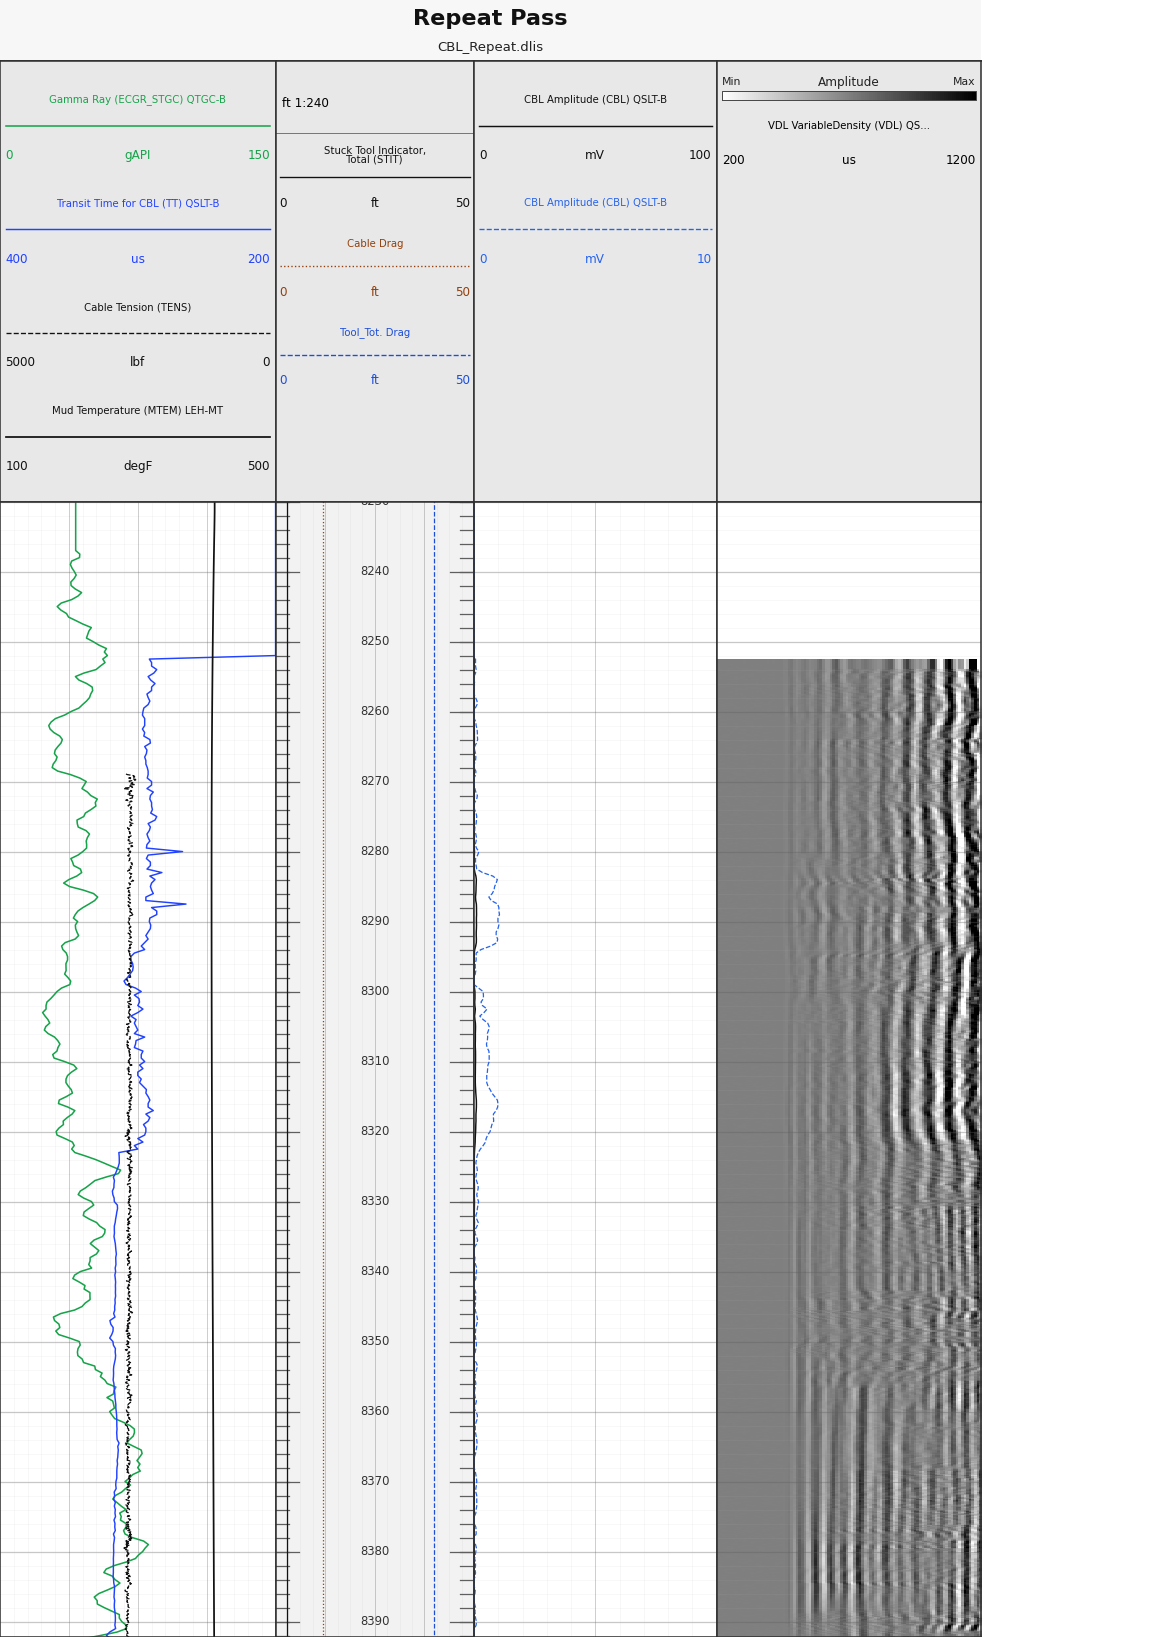

In [11]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_4_final_packet_logfile_path)
result = render_from_logfile(step_4_final_packet_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## How To Adapt This Tutorial To Your Own Well

- Keep the template stable across jobs and change the logfile first when the source files or intervals change.
- Prove the main pass before you add the repeat pass or heavier raster content.
- Bind the same channel twice only when the second scale really adds interpretation value.
- Keep the IP boundary explicit whenever you compare your rendered packet against a reference vendor PDF.

## When To Open The Developer Notebook

- use the developer notebook only when you want the raw repository example internals, full source dumps, or lower-level implementation details
- developer reference notebook: `examples/notebooks/developer/cbl_log_example.ipynb`
